In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats as stats
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time
from datetime import datetime
import os
import subprocess

pd.set_option('display.max_columns', None)

In [15]:
goodreads_export = f'./data/goodreads_library_export.csv'

if os.path.isfile(goodreads_export):
    os.remove(goodreads_export)
# Export my books
options = Options()
options.add_experimental_option("prefs", {
"download.default_directory": r"C:\Users\Alex\Documents\testing\goodreads-ranker\data",
"download.prompt_for_download": False,
"download.directory_upgrade": True,
"safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=options)
driver.get('https://www.goodreads.com/ap/signin?language=en_US&openid.assoc_handle=amzn_goodreads_web_na&openid.claimed_id=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.identity=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0%2Fidentifier_select&openid.mode=checkid_setup&openid.ns=http%3A%2F%2Fspecs.openid.net%2Fauth%2F2.0&openid.pape.max_auth_age=0&openid.return_to=https%3A%2F%2Fwww.goodreads.com%2Fap-handler%2Fsign-in')

print("Press 0 and Enter to continue...")
while True:
    time.sleep(5)
    user_input = input()
    if user_input:
        break

WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.CLASS_NAME, "homePrimaryColumn")))
driver.get('https://www.goodreads.com/review/import')
time.sleep(2)

goodreads_current_date = datetime.now().strftime('%m/%d/%Y')
file = driver.find_element(By.CLASS_NAME, 'fileList')
if goodreads_current_date not in file.text:
    export_button = driver.find_element(By.CLASS_NAME, 'js-LibraryExport')
    export_button.click()

WebDriverWait(driver, 60).until(EC.presence_of_element_located((By.CLASS_NAME, "fileList")))

while True:
    file = driver.find_element(By.CLASS_NAME, 'fileList')
    if goodreads_current_date in file.text:
        # find the link and click it
        link = file.find_element(By.TAG_NAME, 'a')
        link.click()
        time.sleep(1)
        break
    else:
        time.sleep(5)

driver.quit()

Press 0 and Enter to continue...


In [16]:
df1 = pd.read_csv(goodreads_export)
df1['Original Publication Year'] = df1['Original Publication Year'].fillna(df1['Year Published'])

df1 = df1.drop(['Author l-f', 'Additional Authors', 'ISBN', 'ISBN13', 'Binding', 'My Review', 'Date Read', 'Date Added', 'Bookshelves with positions', 'Bookshelves', 'Exclusive Shelf', 'Spoiler', 'Private Notes', 'Year Published', 'Read Count', 'Owned Copies'], axis=1)

with open(f'./data/book_ids.txt', 'w', encoding='utf-8') as f:
    for index, row in df1.iterrows():
        f.write(f'{row["Book Id"]}\n')

In [17]:
!python get_books.py --book_ids_path .\data\ --output_directory_path .\data\

518
3
2024-05-02 17:47:25.639840 get_books.py: Scraping 32839245...
2024-05-02 17:47:25.639840 get_books.py: #1 out of 521 books
============================= Skipping book 32839245 because the script tag was not found.
2024-05-02 17:47:26.287595 get_books.py: Scraping 17869520...
2024-05-02 17:47:26.287595 get_books.py: #2 out of 521 books
============================= Skipping book 17869520 because the script tag was not found.
2024-05-02 17:47:27.260478 get_books.py: Scraping 48579471...
2024-05-02 17:47:27.260478 get_books.py: #3 out of 521 books
============================= Skipping book 48579471 because the script tag was not found.
2024-05-02 17:47:28.099351 get_books.py:

🎉 Success! All book metadata scraped. 🎉

Metadata files have been output to /.\data\
Goodreads scraping run time = ⏰ 0:00:02.469098 ⏰


### Once you have scraped for more info

In [18]:
current_month = datetime.now().strftime('%m-%Y')
df2 = pd.read_csv(f'./data/{current_month}_goodreads_scraped.csv')
df = df1.merge(df2, left_on='Book Id', right_on='book_id', how='inner')
df = df.drop(['Book Id', 'Title', 'average_rating'], axis=1)
df = df.rename(columns={'Author': 'author', 'Number of Pages': 'num_pages', 'Original Publication Year': 'year', 'My Rating': 'my_rating', 'Publisher': 'publisher', 'Average Rating': 'average_rating'})

df.rating_distribution = df.rating_distribution.apply(eval)
df.genres = df.genres.apply(eval)
df['age'] = int(datetime.now().strftime('%Y')) - df.year
median_age = df.age.median()
df.age = df.age.fillna(median_age)
median_num_pages = df.num_pages.median()
df.num_pages = df.num_pages.fillna(median_num_pages)
df.my_rating = df.my_rating.replace(0, np.nan)

def normalize_dict(d):
    max_value = max(d.values())
    return {f'num_{k}star_rating': v / max_value for k, v in d.items()}

df = pd.concat([df, df['rating_distribution'].apply(normalize_dict).apply(pd.Series)], axis=1)

# Elaborate rating distribution

### Normalize ratings

In [19]:
def fit_quadratic(row):
    x = np.array([1, 2, 3, 4, 5])
    a, b, c = np.polyfit(x, row, 2)
    return pd.Series([2*a, b, c])

# Apply the function to each row
coefficients = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].apply(fit_quadratic, axis=1)

# Create the new columns from the result
df['2a'], df['b'], df['c'] = coefficients[0], coefficients[1], coefficients[2]

scaler = MinMaxScaler()
df['num_ratings_log'] = np.log1p(df['num_ratings'])
df['age_log'] = np.log1p(df['age'])
df['num_pages_log'] = np.log1p(df['num_pages'])
df['average_rating_norm'] = scaler.fit_transform(df[['average_rating']])
df['average_rating_norm'] = df['average_rating_norm'] - 0.5

In [20]:
# # The idea is that if a book has only a few ratings, the Bayesian adjusted rating will be closer to the overall mean rating, while if a book has many ratings, the Bayesian adjusted rating will be closer to the book’s raw average rating.
# def bayesian_rating(df):
#   mean = df['average_rating'].mean()
#   std = df['average_rating'].std()
#   df['bayesian_rating'] = (df['average_rating'] * df['num_ratings'] + mean * std**2) / (df['num_ratings'] + std**2)
#   return df

# df = bayesian_rating(df)

In [21]:
# Calculate the mean and standard deviation of the ratings
df['mean_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].mean(axis=1)
df['std_rating'] = df[['num_1star_rating','num_2star_rating','num_3star_rating','num_4star_rating','num_5star_rating']].std(axis=1)

# Calculate the standard error of the mean
df['sem_score'] = df['std_rating'] / np.sqrt(df['num_ratings_log'])
df = df.drop(['mean_rating', 'std_rating'], axis=1)

In [22]:
# # df['weighted_rating'] = (df.average_rating * df.num_ratings_log) / (df.num_pages_log)
# df['relative_weighted_rating'] = (df.average_rating_norm * df.num_ratings_log) / (df.num_pages_log)
# df['sem_rating'] = df.average_rating / (df.num_pages_log * df.sem_score)
df['relative_sem_rating'] = df.average_rating_norm / (df.num_pages_log * df.sem_score)

# df['trend_rating'] = (df['2a']-df.b+df.c)/df.num_pages_log
# df['trend_rating'] = (df['2a']-df.b)/df.num_pages_log # almost identical to the last
df['trend_rating'] = (df['2a'])/df.num_pages_log # favors promising books with fewer reviews

# Final ranking
# df['weighted_rank'] = df['weighted_rating'].rank(method='min')
# df['relative_weighted_rank'] = df['relative_weighted_rating'].rank(method='min')
# df['sem_rank'] = df['sem_rating'].rank(method='min')
df['relative_sem_rank'] = df['relative_sem_rating'].rank(method='min')
df['trend_rank'] = df['trend_rating'].rank(method='min')
df['final_rating'] = df.trend_rank + df.relative_sem_rank # + df.relative_weighted_rank

In [23]:
df = df[['book_id', 'book_title', 'book_series', 'author', 'publisher', 'num_pages', 'year', 'my_rating', 'num_ratings', 'num_reviews', 'average_rating', 'rating_distribution', 'genres', 'relative_sem_rating', 'trend_rating','final_rating']]

In [24]:
df.sort_values(by='final_rating', ascending=False).head(30)
# df.sort_values(by='relative_sem_rating', ascending=False)
# df.sort_values(by='trend_rating', ascending=False)
df.loc[df['my_rating'].isna(), :].sort_values(by='final_rating', ascending=False).head(30)
df[df['my_rating'].isna() == False].sort_values(by='final_rating', ascending=False).head(30)

,book_id,book_title,book_series,author,publisher,num_pages,year,my_rating,num_ratings,num_reviews,average_rating,rating_distribution,genres,relative_sem_rating,trend_rating,final_rating
25,17563539,The Egg,NaN,Andy Weir,Andy Weir / Galactanet,3.0,2009.0,4.0,31032,3872,4.22,"{'5': 14400, '4': 10813, '3': 4434, '2': 963, ...","[Short Stories, Fiction, Science Fiction, Phil...",0.784231,0.064406,1036.0
263,3,Harry Potter and the Sorcerer's Stone,Book 1 in the Harry Potter series,J.K. Rowling,Scholastic Inc,309.0,1997.0,5.0,10091305,163056,4.47,"{'5': 6529304, '4': 2341868, '3': 854727, '2':...","[Fantasy, Fiction, Young Adult, Magic, Childre...",0.557928,0.034918,1017.0
67,186074,The Name of the Wind,Book 1 in the The Kingkiller Chronicle series,Patrick Rothfuss,Penguin Group DAW,662.0,2007.0,5.0,965386,54451,4.52,"{'5': 657540, '4': 204830, '3': 66236, '2': 21...","[Fantasy, Fiction, Epic Fantasy, High Fantasy,...",0.502964,0.032990,1010.0
311,8662312,Breakthrough Advertising,NaN,Eugene M. Schwartz,Bottom Line Books,236.0,1966.0,5.0,965,99,4.53,"{'5': 660, '4': 205, '3': 68, '2': 17, '1': 15}","[Business, Writing, Nonfiction, Psychology, En...",0.429521,0.039268,1007.0
262,37905646,Pricing Creativity: A Guide to Profit Beyond t...,NaN,Blair Enns,NaN,316.0,NaN,5.0,157,13,4.62,"{'5': 112, '4': 35, '3': 7, '2': 2, '1': 1}","[Business, Design, Nonfiction, Entrepreneurshi...",0.403495,0.038760,996.0
339,38746485,Becoming,NaN,Michelle Obama,Crown,426.0,2018.0,4.0,1052619,67569,4.46,"{'5': 647098, '4': 290777, '3': 81512, '2': 16...","[Nonfiction, Memoir, Biography, Audiobook, Aut...",0.472019,0.031279,994.0
198,54493401,Project Hail Mary,NaN,Andy Weir,Ballantine Books,476.0,2021.0,5.0,574530,71616,4.51,"{'5': 361521, '4': 159202, '3': 42340, '2': 86...","[Science Fiction, Fiction, Audiobook, Fantasy,...",0.500037,0.030504,993.0
39,42362866,Think Like a UX Researcher: How to Observe Use...,NaN,David Travis,CRC Press,294.0,2019.0,5.0,272,31,4.58,"{'5': 185, '4': 65, '3': 18, '2': 4, '1': 0}","[Design, Research, Nonfiction, Business, Refer...",0.403688,0.035983,992.0
98,27220736,Shoe Dog: A Memoir by the Creator of Nike,NaN,Phil Knight,Scribner,400.0,2016.0,5.0,300530,18252,4.47,"{'5': 185124, '4': 83509, '3': 23555, '2': 510...","[Business, Biography, Nonfiction, Memoir, Spor...",0.463971,0.031028,989.0
202,8735747,The Forgotten Highlander: My Incredible Story ...,NaN,Alistair Urquhart,Hachette Digital,321.0,2010.0,5.0,4326,381,4.51,"{'5': 2686, '4': 1255, '3': 309, '2': 54, '1':...","[History, Nonfiction, Biography, War, Military...",0.421353,0.032135,984.0


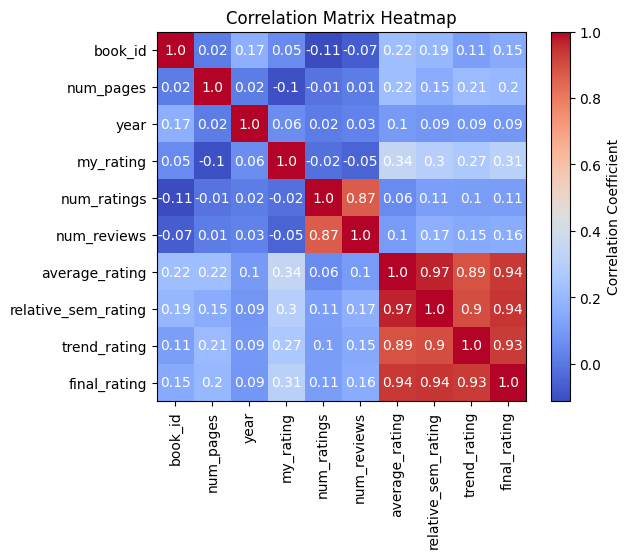

In [12]:
correlation_matrix = df.drop(['genres', 'rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, round(correlation_matrix.iloc[i, j], 2),
                       ha="center", va="center", color="w")

# Display the plot
plt.show()

In [13]:
# correlation_matrix.sort_values(by='2a', ascending=False)

# Elaborate genres and rating_dist columns

In [14]:
df_exploded = df.explode('genres')
genres_dummies = pd.get_dummies(df_exploded['genres'])

df_exploded = pd.concat([df_exploded, genres_dummies], axis=1)

agg_dict = {col: 'first' for col in df_exploded.columns.difference(['genres']+list(genres_dummies.columns))}
agg_dict.update({col: 'sum' for col in genres_dummies.columns})

df_genres = df_exploded.groupby('book_id', as_index=False).agg(agg_dict)


In [15]:
# drop uncommon genres
mean_genres = pd.Series(genres_dummies.mean(), index=genres_dummies.columns)
for column in df_genres.columns:
    if column in mean_genres.index and mean_genres.loc[column] < mean_genres.mean():
        df_genres = df_genres.drop(column, axis=1)

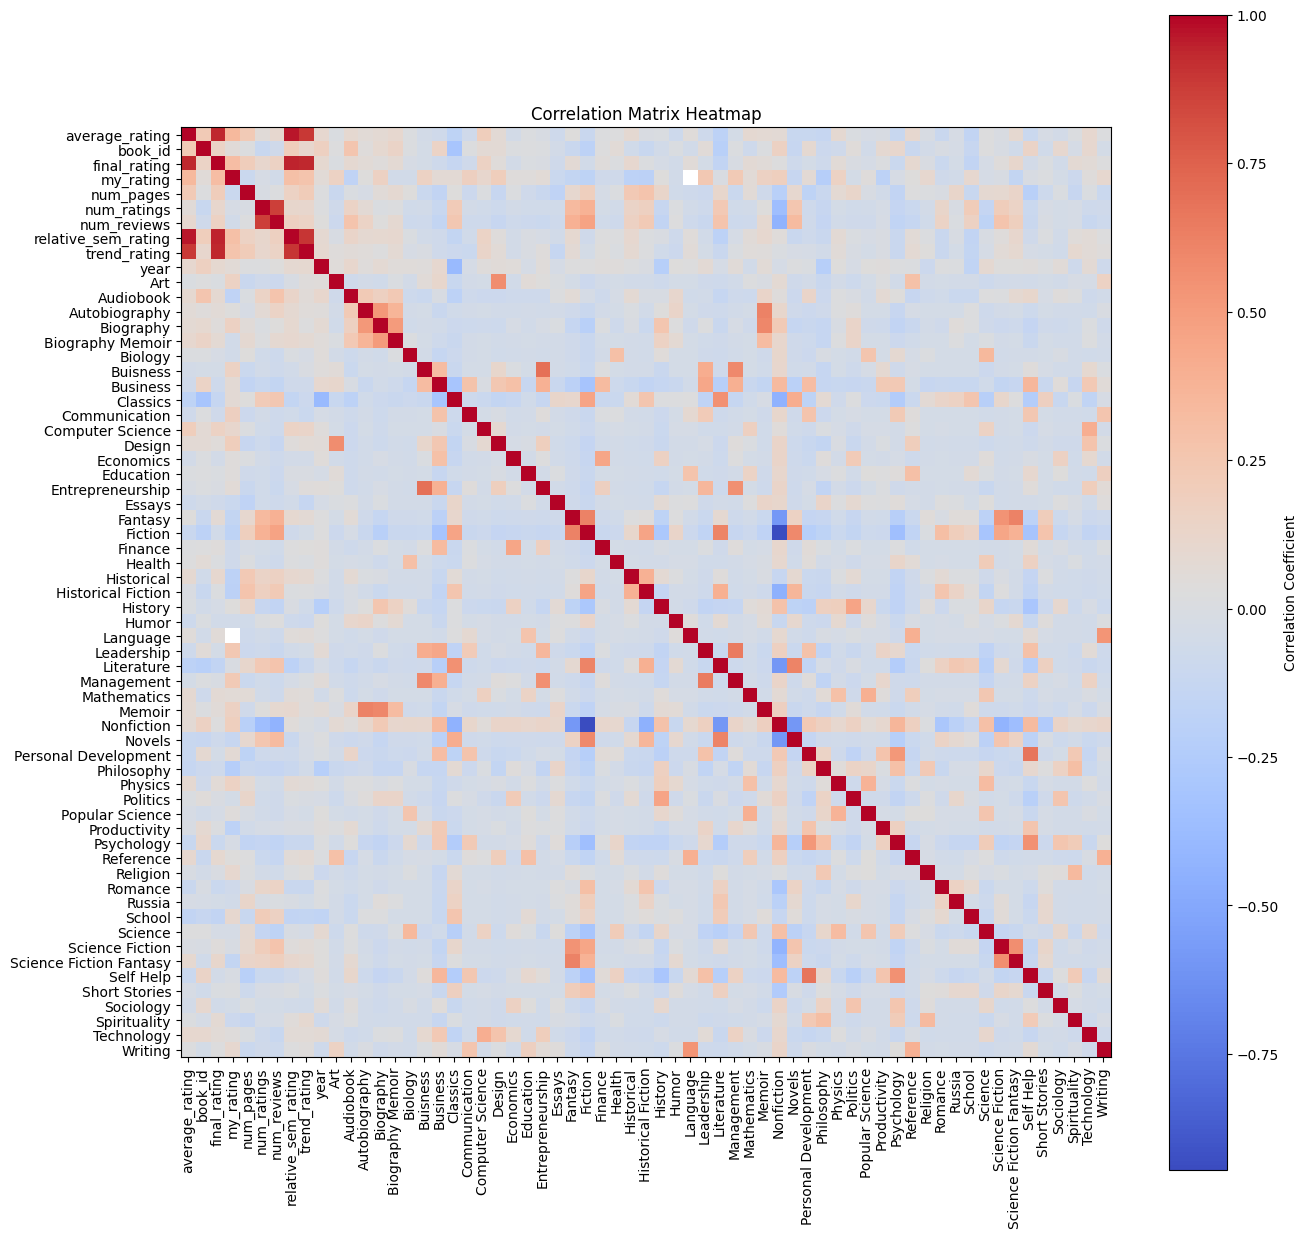

In [16]:
correlation_matrix = df_genres.drop(['rating_distribution', 'author', 'book_title', 'book_series', 'publisher'], axis=1).corr()
plt.figure(figsize=(15,15))
plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()

In [17]:
correlation_matrix.sort_values(by='my_rating', ascending=False).head(30)


,average_rating,book_id,final_rating,my_rating,num_pages,num_ratings,num_reviews,relative_sem_rating,trend_rating,year,Art,Audiobook,Autobiography,Biography,Biography Memoir,Biology,Buisness,Business,Classics,Communication,Computer Science,Design,Economics,Education,Entrepreneurship,Essays,Fantasy,Fiction,Finance,Health,Historical,Historical Fiction,History,Humor,Language,Leadership,Literature,Management,Mathematics,Memoir,Nonfiction,Novels,Personal Development,Philosophy,Physics,Politics,Popular Science,Productivity,Psychology,Reference,Religion,Romance,Russia,School,Science,Science Fiction,Science Fiction Fantasy,Self Help,Short Stories,Sociology,Spirituality,Technology,Writing
my_rating,0.343868,0.053262,0.310113,1.000000,-0.098081,-0.019718,-0.050643,0.297232,0.267428,0.058665,0.153427,-0.162988,0.029035,0.158563,-0.049000,-0.049000,0.153427,0.069740,0.071864,0.175425,0.107801,0.189126,0.041844,0.041844,0.059950,-0.099916,-0.141066,-0.171071,-0.069740,-0.069740,-0.184421,-0.190155,0.029035,-0.049000,NaN,0.235051,-0.006585,0.219815,0.059950,0.158563,0.180876,-0.123307,0.070406,-0.229216,0.153427,-0.040483,0.041844,-0.177663,-0.024584,0.031487,0.097428,-0.069740,-0.049000,0.097428,-0.026074,-0.011560,-0.145175,-0.011059,0.005731,-0.040483,-0.087105,0.041844,0.097428
average_rating,1.000000,0.224064,0.935217,0.343868,0.223767,0.056558,0.100763,0.965846,0.889067,0.097186,-0.002570,0.090909,0.059265,0.079592,0.098606,0.006992,-0.044331,-0.068971,-0.173094,-0.068199,0.190120,0.070751,-0.047207,0.005626,-0.016482,-0.073497,0.033063,-0.101920,0.014359,0.027092,0.081241,-0.005907,0.003379,-0.082166,0.044981,-0.071759,-0.182400,-0.034521,0.085115,0.076142,0.066261,-0.115020,-0.111909,-0.127473,0.084164,0.001183,-0.019489,-0.012950,-0.113738,0.100039,-0.012213,-0.104929,-0.018019,-0.151497,0.024260,-0.007327,0.090457,-0.096581,-0.024982,-0.041071,0.009753,0.097180,0.019140
final_rating,0.935217,0.148390,1.000000,0.310113,0.197749,0.107044,0.155506,0.940158,0.934745,0.088679,0.002280,0.083486,0.059768,0.041914,0.078318,-0.021289,-0.033921,-0.074352,-0.127785,-0.068712,0.150185,0.047764,-0.042373,-0.001520,-0.003534,-0.068685,0.069276,-0.055383,0.037932,0.007925,0.102626,0.004806,-0.033037,-0.053319,0.054774,-0.038427,-0.149792,-0.011951,0.067436,0.052102,0.024727,-0.073789,-0.037450,-0.073121,0.064219,-0.009759,-0.029223,0.005732,-0.101076,0.091920,-0.007046,-0.100578,-0.036342,-0.153837,-0.029439,0.036917,0.112989,-0.042652,-0.002381,-0.055647,0.076007,0.064577,0.024795
relative_sem_rating,0.965846,0.194310,0.940158,0.297232,0.153609,0.111326,0.167894,1.000000,0.898359,0.086218,-0.015091,0.129560,0.087519,0.093562,0.099878,-0.001177,-0.049028,-0.068927,-0.145629,-0.056629,0.142498,0.039954,-0.048153,-0.003518,-0.022000,-0.050522,0.089183,-0.063934,0.020820,0.016434,0.101805,0.007602,-0.010293,-0.072875,0.045386,-0.054498,-0.183668,-0.032051,0.052923,0.102006,0.043563,-0.105934,-0.073310,-0.104872,0.066896,-0.000956,-0.019439,-0.005367,-0.106448,0.063328,0.008549,-0.105121,-0.012677,-0.151794,-0.012231,0.036866,0.109987,-0.071072,0.010873,-0.048860,0.043840,0.065376,0.022556
trend_rating,0.889067,0.109780,0.934745,0.267428,0.209244,0.104937,0.145642,0.898359,1.000000,0.094739,0.037081,0.052101,0.048357,0.025777,0.075825,-0.019789,-0.007619,-0.063646,-0.091991,-0.094473,0.131467,0.060368,-0.043840,-0.003888,0.035824,-0.125865,0.067344,-0.035004,0.034580,-0.002818,0.083391,0.016123,-0.059380,-0.091764,0.055897,-0.036616,-0.106051,0.004097,0.049841,0.035647,0.003841,-0.019961,-0.029027,-0.052271,0.055246,-0.015922,-0.040274,-0.002991,-0.107658,0.080078,0.032946,-0.108363,-0.034188,-0.146471,-0.029659,0.059298,0.091954,-0.029060,-0.036968,-0.057275,0.095810,0.062126,0.040089
Leadership,-0.071759,0.053243,-0.038427,0.235051,-0.092391,-0.071803,-0.101938,-0.054498,-0.036616,0.069438,-0.069240,-0.053140,-0.064571,0.012999,-0.062951,-0.066158,0.408239,0.438400,-0.165101,0.210826,-0.056079,-0.028429,-0.043120,-0.062951,0.353974,-0.066158,-0.09

In [18]:
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df.sort_values(by='2a', ascending=False))